<a id="sec_main"></a>
# Basic use of Tensorlab

Tensorlab is a Python package for tensor computations. This demo will discuss the basic functionalities of Tensorlab. It consists of three consecutive parts. A first section [Tensor construction and visualization](#sec_1) will explain how a tensor can be defined and visualized. The second section [Canonical polyadic decomposition](#sec_CPD) handles the use of the commands for the computation of the canonical polyadic decomposition, including more advanced items such as customized initialization methods and algorithms. The third section briefly introduces the computation of [Multilinear singular value decomposition](#sec_MLSVD).

Required packages for this demo

In [1]:
import numpy as np
import tensorlab as tl
import scipy.linalg as la
import matplotlib.pyplot as plt
%matplotlib inline

np.set_printoptions(precision=5, suppress=True)
randn = np.random.default_rng(123).standard_normal

<a id="sec_1"></a>
## Tensor construction and visualization

### Construction of a tensor with random entries
A random tensor can be constructed using the basic NumPy commands for generating random ndarrays. For example, we can construct a tensor $ \mathbf{\mathcal{T}} \in \mathbb{R}^{10 \times 20 \times 30}$ with entries randomly sampled from the standard normal distribution as follows:

In [2]:
tens_shape = (10, 20, 30)
T = randn(tens_shape)

<a id="sec_PD"></a>
### Construction of a tensor as a sum of R rank-1 terms

To construct a third-order tensor $ \mathbf{\mathcal{T}} \in \mathbb{R}^{I \times J \times K} $ which can be written as a sum of $ R$ rank-1 terms, we start with the construction of the three factor matrices $ \mathbf{U}^{(1)} \in \mathbb{R}^{I \times R}, \mathbf{U}^{(2)} \in \mathbb{R}^{J \times R}, \text{ and } \mathbf{U}^{(3)} \in \mathbb{R}^{K \times R}, $ corresponding to the three different modes. This can be done with the command ``tl.PolyadicTensor.random`` :

In [3]:
# Create a random PolyadicTensor as a sum of R rank-1 terms.
R = 4
Tcp = tl.PolyadicTensor.random(shape=tens_shape, nterm=R)   # Tcp: PolyadicTensor
# See also tl.PolyadicTensor.rand, tl.PolyadicTensor.randn.

Note that ``Tcp`` is a PolyadicTensor that has the attribute factors (``Tcp.factors``), which contain the factor matrices.

To obtain the full tensor from a PolyadicTensor, you can use the commands ``np.array(Tcp)`` or ``np.asarray(Tcp)``

In [4]:
Tfull = np.array(Tcp)  

For a graphical representation, we refer to Figure 1.
<figure id="fig1">
    <img src="_images\cpd2.svg" alt="Visualization of a polyadic decomposition.">
    <figcaption>Figure 1: Visualization of a polyadic decomposition.</figcaption>
</figure>


Note that it is possible to construct complex factor matrices and tensors too by setting the generator arguments ``imag`` and ``real``.


In [5]:
Tcp = tl.PolyadicTensor.random(
    shape=tens_shape,
    nterm=R,
    real=randn,
    imag=randn,
)

### Construction of a tensor obtained by a multilinear transformation of a core tensor

We start with the construction of the core tensor and the transformation matrices using  the ``tl.TuckerTensor.random`` command.


In [6]:
tens_shape = (10, 20, 30)
core_shape = (4, 5, 6)
Tt = tl.TuckerTensor.random(tens_shape, core_shape)   # Tt: TuckerTensor

``Tt`` is a TuckerTensor with the attributes (``Tt.core`` and ``Tt.factors``), which are the core tensor and the factor matrices, respectively.

The full tensor can be obtained through the tensor-matrix product of the core tensor with the different matrices, or one can simply use the ``np.array(Tt)`` command.

In [7]:
Tfull = np.array(Tt)  
#Alternatively, you can use tensor-matrix product, as shown below.
Tfull2 = tl.tmprod(Tt.core, Tt.factors, range(Tt.ndim))

# Check if the result is the same.
np.allclose(Tfull, Tfull2) 

True

For a graphical representation of the multilinear product, we refer to Figure 2.

![](_images\lmlra.svg)<br>

Figure 2: Visualization of the multilinear product of a core tensor $ \mathcal{S} $ with factor matrices $ \mathbf {U, V, \text { and } W}. $

### Perturbation of a tensor by noise

A tensor can be perturbed by Gaussian noise with a user-defined signal-to-noise ratio using the command ``tl.noisy``, as shown below.

In [8]:
# Signal-to-noise ratio
SNR = 20
Tnoisy = tl.noisy(Tfull, SNR)

# We can also pass other tensor types directly, like T : TuckerTensor or PolyadicTensor.
# Tnoisy = tl.noisy(T,SNR)

### Visualization 

Tensorlab offers three commands for visualizing third-order tensors: ``tl.slice3``, ``tl.surf3``, and ``tl.voxel3``. The plots of the first two commands contain sliders to go through the different slices. The ``tl.voxel3`` command plots the elements of a tensor as voxels whose color and opacity are proportional to the value of the elements. The plot has two sliders for the threshold parameter and the degree parameter.

In [9]:
# Generate a tensor
t = np.linspace(0, 1, 60).reshape(-1, 1)
T = tl.PolyadicTensor([np.sin(2*np.pi*t+np.pi/4), np.sin(4*np.pi*t+np.pi/4), np.sin(6*np.pi*t+np.pi/4)])

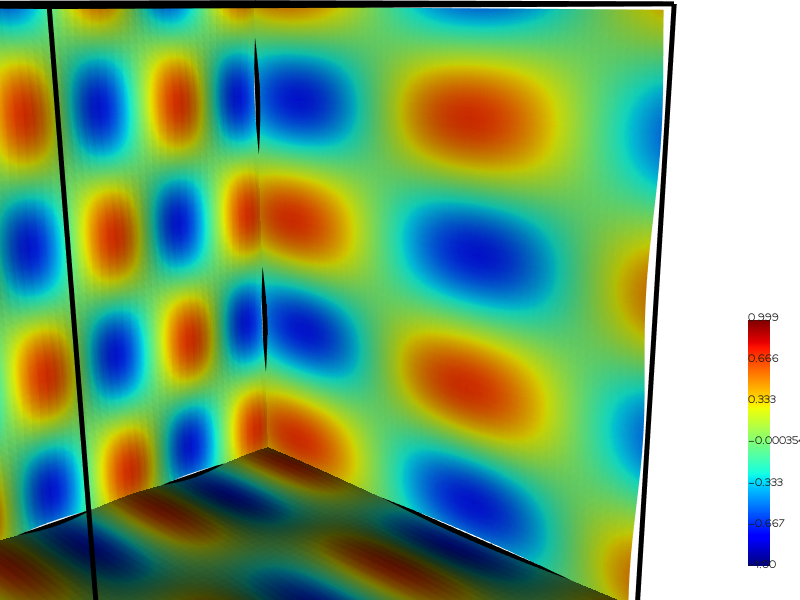

In [10]:
# The following command plots slices as surfaces.
tl.surf3(T, interactive=True)  

To plot the slices at specific mode indices, we can pass the ``ind`` parameter.

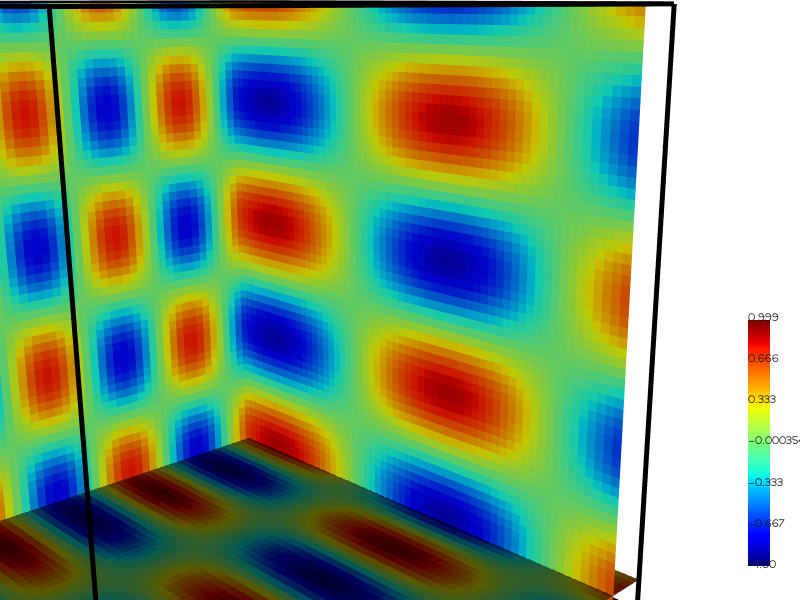

In [11]:
tl.slice3(T, ind=(1, 3, 4))

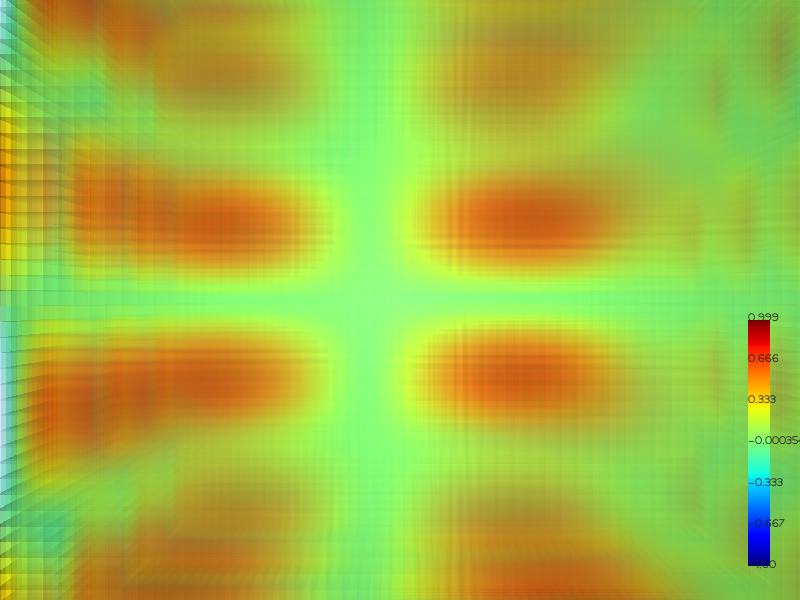

In [12]:
tl.voxel3(T)

<a id="sec_CPD"></a>
## Canonical Polyadic Decomposition

### CPD for beginners

Let us consider a tensor $ \mathcal{T}$ that approximately has a low rank, constructed, for example, using one of the techniques from the section, [Construction of a tensor as a sum of R rank-1 terms](#sec_PD). We discuss the use of the basic CPD commands and the calculation of two different error measures.

In [13]:
# Generate a rank-4 CPD tensor of shape 10 x 20 x 30.
Tcp = tl.PolyadicTensor.randn(shape=(10, 20, 30), nterm=4)  # Tcp: PolyadicTensor

Tfull = np.array(Tcp)  

__The basic CPD command__<br>

The command ``tl.cpd_gevd`` computes CPD using generalized eigenvalue decomposition, and it requires only a tensor and a value for the rank.


In [14]:
R = 4
Tes = tl.cpd_gevd(T=Tfull, nterm = R)

__Error measures__<br>

The relative error in the estimates of the factor matrices can be calculated using the ``error`` attribute of the PolyadicTensor. This attribute takes into account the permutation and scaling indeterminacies and returns the relative errors for each factor matrix. To obtain the permutation indices for matching factor vectors, the ``tl.match_congruence_kr`` command can be used.

In [15]:
# Computes the relative error between the factor matrices of the original tensor (Tcp) and its approximation/estimation (Tes_nls)
Tcp.error(Tes)

[2.4703835201071925e-16, 3.9218064064251417e-16, 4.2400824500811317e-16]

The relative error on the estimate of the tensor can be determined using the ``tl.frob`` command.

In [16]:
# Compute the relative error between Tcp and Tes_nls.
tl.frob(Tes + (-Tcp)) / tl.frob(Tcp)

1.0328868847480138e-15

### CPD for pros

In general, the CPD computation consists of a compression step, a step in which the CPD of the compressed tensor is computed, and a step in which the estimates are refined using the uncompressed tensor. The user has control over what happens in each step. In this section, we discuss the different steps in more detail.

__Compression__ <br>



In [17]:
# TODO

__Initialization__ <br>

 To initialize the computation of the CPD of the tensor, the results of the generalized eigenvalue decomposition is used if the rank does not exceed the second largest dimension of the tensor. Otherwise, random initialization is used. The initialization method can be altered with the initialization argument ``U0`` :

In [18]:
# Random initilization.
T_init = tl.PolyadicTensor.rand(shape=(10, 20, 30), nterm=4) 

# opts =  tl.CPDNlsOptions(tol_relfval=1e-32, tol_relstep=1e-9)
# CPD-ALS initialization.
Tes_als, logger_als = tl.cpd_als(T=Tfull, U0=T_init)

In the above example, a random initialization is chosen. The user can also provide a list of factor matrices (``Uinit``) to create the initialization: ``T_init = tl.PolyadicTensor(Uinit)``

__Core algorithms__ <br>

Tensorlab provides several core algorithms for the computation of a CPD. There are optimization-based methods such as ``tl.cpd_als`` (alternating least squares), ``tl.cpd_minf`` (unconstrained nonlinear optimization), and ``tl.cpd_nls`` (nonlinear least squares). The ``tl.cpd_gevd`` command computes the CPD by a generalized eigenvalue decomposition. <br>

__Algorithm parameters__ <br>

For the algorithms, ``tl.cpd_nls`` and ``tl.cpd_minf``, the ``method`` parameter is used to provide the optimization method. Currently, the following methods are supported: 'newton-cg', 'trust-krylov' and 'trust-ncg' for  ``tl.cpd_nls`` and   'bfgs', 'cg',  'l-bfgs-b' for ``tl.cpd_minf``.
 
  Four parameters affect the stopping criterion. The parameter ``max_iter`` determines the maximum number of iterations. The parameters ``tol_relfval`` and  ``tol_absfval`` are tolerances for relative and absolute changes in objective function values, respectively. The parameter ``tol_relstep`` is the tolerance for the step size. 

The following piece of code illustrates how these parameters can be changed for the ``tl.cpd_nls`` and ``tl.cpd_als``. algorithms:

In [19]:
# CPD-ALS command with parameters.
# opts =  tl.CPDAlsOptions(tol_relfval=1e-32, tol_relstep=1e-9)
Tes_als, logger_als = tl.cpd_als(
    T=Tfull, U0=T_init, max_iter=100, tol_relfval=1e-12, tol_relstep=1e-6
)

In [20]:
# Run the CPD-NLS command.
# opts =  tl.CPDNlsOptions(tol_relfval=1e-32, tol_relstep=1e-9)
Tes_nls, logger_nls = tl.cpd_nls(
    T=Tfull,
    U0=T_init,
    method="newton-cg",
    max_iter=100,
    tol_relfval=1e-12,
    tol_relstep=1e-6,
)

Convergence plots can be obtained by plotting the objective function values from the respective output logger:

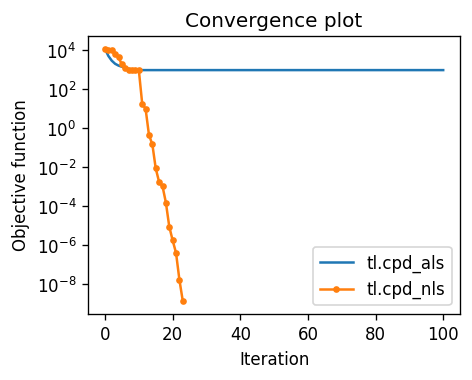

In [21]:
plt.figure(figsize=(4, 3), dpi=120)
plt.semilogy(logger_als.fval, "-", label="tl.cpd_als")
plt.semilogy(logger_nls.fval, ".-", label="tl.cpd_nls")
plt.ylabel("Objective function")
plt.xlabel("Iteration")
plt.title("Convergence plot")
plt.legend()
plt.show()

<a id="sec_MLSVD"></a>
## Multilinear singular value decomposition and low multilinear rank approximation 

Let us consider a tensor $ \mathcal{T} \in \mathbb{R}^{10\times 20 \times 30}$. The multilinear singular value decomposition (MLSVD) of $ \mathcal{T}$ is a decomposition of the form

$$
  \mathbf{\mathcal{T}}  = \mathcal{S} \boldsymbol{\cdot}_1 \mathbf{U}^{(1)} \boldsymbol{\cdot}_2 \mathbf{U}^{(2)}
  \boldsymbol{\cdot}_3 \mathbf{U}^{(3)}
$$

with $ \mathcal{S}\in \mathbb{R}^{10\times 20 \times 30}$ an all-orthogonal and ordered tensor. The factor matrices $ \mathbf{U}^{(1)}\in \mathbb{R}^{10\times 10}$, $ \mathbf{U}^{(2)}\in \mathbb{R}^{20\times 20}$ and $ \mathbf{U}^{(3)}\in \mathbb{R}^{30\times 30}$ have orthonormal columns. This decomposition can be calculated using the ``tl.mlsvd`` command. In the following example, a tensor with random entries is decomposed:

In [22]:
# Generate a random tensor of shape 10 x 20 x 30.
tens_shape = (10, 20, 30)
T = randn(tens_shape)

# Run the MLSVD
Tmlsvd, sv = tl.mlsvd(T)  #  Tmlsvd: TuckerTensor format

Tmlsvd.core.shape    # S : 10 x 20 x 30

(10, 20, 30)

The mode-n singular values are stored in ``sv``. A truncated MLSVD can be obtained by providing the desired `coreshape` argument:


In [23]:
coreshape=(2, 2, 3)
Tmlsvd, sv = tl.mlsvd(T, coreshape)
Tmlsvd.core.shape  # truncated core shape: 2 x 2 x 3 

(2, 2, 3)

Note that, due to the truncation, the core tensor may no longer be all-orthogonal and ordered. The truncated MLSVD is just one, not necessarily optimal, way of obtaining a low multilinear rank approximation (LMLRA). A better approximation with the same multilinear rank can be obtained with the ``tl.lmlra`` command:

In [24]:
Topt, logger = tl.lmlra(T, coreshape)


   iters            fval      max angle
 max=500     tol=0.0e+00    tol=1.0e-06

       0    2.998424e+03               
       1    2.907031e+03   9.683674e-01
       2    2.888822e+03   2.352277e-01
       3    2.882418e+03   1.567981e-01
       4    2.879185e+03   1.169557e-01
       5    2.877419e+03   8.822445e-02
       6    2.876385e+03   6.678141e-02
       7    2.875715e+03   5.205891e-02
       8    2.875235e+03   4.221404e-02
       9    2.874864e+03   3.538263e-02
      10    2.874561e+03   3.031028e-02
      11    2.874302e+03   2.669483e-02
      12    2.874072e+03   2.471792e-02
      13    2.873865e+03   2.336186e-02
      14    2.873674e+03   2.223923e-02
      15    2.873499e+03   2.116079e-02
      16    2.873339e+03   2.001230e-02
      17    2.873197e+03   1.873872e-02
      18    2.873072e+03   1.733188e-02
      19    2.872965e+03   1.581708e-02

   iters            fval      max angle
 max=500     tol=0.0e+00    tol=1.0e-06

      20    2.872877e+03   1.423971e

Similar to the CPD commands explained above, the initialization and core algorithms can be altered using the ``initialization`` and ``optimization_method`` arguments in the ``tl.lmlra`` command. Various LMLRA core algorithms are available; we refer to the documentation of the ``tl.lmlra`` command for more information.

For a more in-depth discussion of MLSVD and LMLRA, we refer to the demo [Multilinear singular value decomposition and low multilinear rank approximation.](./demo_mlsvd.ipynb)